# Entropy-SGD optimizes the prior of a PAC-Bayes bound: Generalization properties of Entropy-SGD and data-dependent priors

## Alexandre MALLEZ - Swann CORDIER
### Bayesian Machine Learning - Project

---

### Import

In [ ]:
import torch
import torch.nn as nn
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import numpy as np
import copy
import scipy.optimize as opt

---

### Used model : FC600

In [ ]:
class FC600(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 600)
        self.fc2 = nn.Linear(600, 600)
        self.fc3 = nn.Linear(600, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x)) 
        return x

Bounded Binary Cross-Entropy Loss function

In [ ]:
def bounded_binary_cross_entropy_loss(probs, targets, L_max=4.0):  

    probs = probs.squeeze()
    targets = targets.float().squeeze()
    
    e_minus_L = math.exp(-L_max)
    psi_p = e_minus_L + (1.0 - 2.0 * e_minus_L) * probs
    
    loss = -targets * torch.log(psi_p) - (1.0 - targets) * torch.log(1.0 - psi_p)
    
    return loss.mean()

### Algortithm 1 : Entropy-SGLD Step

In [ ]:

def entropy_sgld_step(model, batches_list, t_outer, m=60000, L=20, gamma=1.0, tau=math.sqrt(60000), beta=1.0, alpha=0.75, eta_prime_base=0.1):
    device = next(model.parameters()).device
    
    # Copies
    w_base = [p.clone().detach().to(device) for p in model.parameters()]
    w_params = list(model.parameters())
    mu_params = [p.clone().detach().to(device) for p in w_base]
    w_prime_params = [p.clone().detach().to(device) for p in w_base]
    
    # Intern loop
    for i, (inputs, targets) in enumerate(batches_list, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Injecting the current model parameters into w_prime for the inner loop
        for p, p_prime in zip(w_params, w_prime_params):
            p.data.copy_(p_prime.data)
            
        probs = model(inputs)
        loss = bounded_binary_cross_entropy_loss(probs, targets) # bounded binary cross-entropy loss
        
        model.zero_grad()
        loss.backward()
        
        # eta_inner_rescaled = 2 / (i * tau) Paper suggestion but we augment it for faster convergence
        eta_inner_rescaled = 0.2 / i
        
        with torch.no_grad():
            for p_prime, p_orig, p_model in zip(w_prime_params, w_base, model.parameters()):
                dw = - p_model.grad - gamma * (p_prime - p_orig)
            
                noise = torch.randn_like(p_prime) * math.sqrt(eta_inner_rescaled * 2.0 / tau) / 2  # Reducing noise by half to mitigate divergence
                
                p_prime.add_(eta_inner_rescaled * dw)
                p_prime.add_(noise)
                
        # mu update
        for m_p, p_prime in zip(mu_params, w_prime_params):
            m_p.data = (1.0 - alpha) * m_p.data + alpha * p_prime.data
            
    # Extern loop
    eta = eta_prime_base / (gamma * tau)
    eta_t = eta * (t_outer ** -0.6)
    
    with torch.no_grad():
        for p_base, m_p, p in zip(w_base, mu_params, model.parameters()):
            ascent_term = 0.5 * eta_t * tau * gamma * (p_base.data - m_p.data)
            noise = torch.randn_like(p_base) * math.sqrt(eta_t / beta)  # Removing noise because of divergence issues, can last a day according to writers

            p.data.copy_(p_base.data - ascent_term + noise)

---

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

### Test on Binary MNIST 

In [53]:

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Binary transformation
# labels under 5 become 1 (True), the rest become 0 (False)
train_dataset.targets = (train_dataset.targets < 5).long()
test_dataset.targets = (test_dataset.targets < 5).long()

K = 128
train_loader = DataLoader(train_dataset, batch_size=K, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=K, shuffle=False)

Hyperparametres : 

In [ ]:
m = len(train_dataset)  # 60000
L = 20
gamma = 1.0
tau = math.sqrt(m)
beta = 100.0 # high beta so bad PAC Bound but we want to see some learning
alpha = 0.75
eta_prime_base = 1 # way higher than the paper's 0.0006 to get some learning in a reasonable time frame (and since we have no noise in the outer loop )


num_epochs = 50
global_t_outer = 1
steps_per_epoch = len(train_loader) // L 


In [ ]:
print(f"Training on {device}...")

model_0 = FC600().to(device)

error_test_history_0 = []
error_train_history_0 = []

for epoch in range(1, num_epochs + 1):
    # Training
    model_0.train()
    
    data_iter = iter(train_loader)
    
    for step in range(steps_per_epoch):
        batches_list = []
        for _ in range(L):
            batches_list.append(next(data_iter))
            
        # entropy_sgld_step
        entropy_sgld_step(model_0, batches_list, global_t_outer, m=m, L=L, gamma=gamma, tau=tau, beta=beta, alpha=alpha, eta_prime_base=eta_prime_base)
        global_t_outer += 1
        
    # Evaluation
    model_0.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_0(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_test = (1 - correct / total)*100

        error_test_history_0.append(error_test/100)

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_0(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_train = (1 - correct / total)*100

        error_train_history_0.append(error_train/100)

    print(f"Epoch {epoch}/{num_epochs} completed | Train Error: {error_train:.2f}% | Test Error: {error_test:.2f}% ")

Training on cuda...
Epoch 1/50 completed | Train Error: 30.21% | Test Error: 29.29% 
Epoch 2/50 completed | Train Error: 21.66% | Test Error: 21.01% 
Epoch 3/50 completed | Train Error: 20.95% | Test Error: 20.18% 
Epoch 4/50 completed | Train Error: 20.51% | Test Error: 20.08% 
Epoch 5/50 completed | Train Error: 20.17% | Test Error: 19.58% 
Epoch 6/50 completed | Train Error: 19.61% | Test Error: 19.18% 
Epoch 7/50 completed | Train Error: 19.35% | Test Error: 18.83% 
Epoch 8/50 completed | Train Error: 18.75% | Test Error: 17.95% 
Epoch 9/50 completed | Train Error: 18.12% | Test Error: 17.58% 
Epoch 10/50 completed | Train Error: 17.89% | Test Error: 17.22% 
Epoch 11/50 completed | Train Error: 17.59% | Test Error: 17.08% 
Epoch 12/50 completed | Train Error: 17.19% | Test Error: 16.60% 
Epoch 13/50 completed | Train Error: 17.07% | Test Error: 16.63% 
Epoch 14/50 completed | Train Error: 16.89% | Test Error: 16.31% 
Epoch 15/50 completed | Train Error: 16.34% | Test Error: 15.80% 

In [125]:
def plot_error_history(train_errors_history, test_errors_history, num_epochs, title = 'Classification Error History'):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs + 1), train_errors_history, label='Train error', marker='o', linestyle='-', color='purple')
    plt.plot(range(1, num_epochs + 1), test_errors_history, label='Test error', marker='s', linestyle='--', color='gray')

    plt.xlabel('Epochs')
    plt.ylabel('0-1 error')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


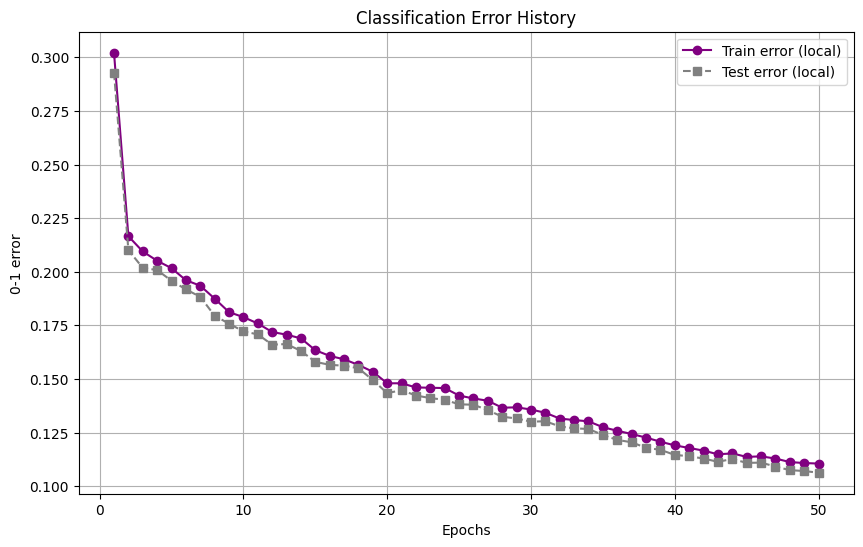

In [83]:
plot_error_history(error_train_history_0, error_test_history_0, num_epochs)

It keep decreasing all the way, with more epochs we could attain even better errors, beside test error is consistently under train error which is nice. 

---

### Random Label with Binary MNIST : Check of overfitting

In [45]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset_random = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_random = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Binary transformation
# labels under 5 become 1 (True), the rest become 0 (False)
train_dataset_random.targets = np.random.randint(0, 2, size=train_dataset_random.targets.shape[0])  # Random binary labels
test_dataset_random.targets = np.random.randint(0, 2, size=test_dataset_random.targets.shape[0])  # Random binary labels

K = 128
train_loader_random = DataLoader(train_dataset_random, batch_size=K, shuffle=True)
test_loader_random = DataLoader(test_dataset_random, batch_size=K, shuffle=False)

In [86]:
print(f"Training on {device}...")

num_epochs = 10

model_random = FC600().to(device)

error_test_history_random = []
error_train_history_random = []

for epoch in range(1, num_epochs + 1):
    # Training
    model_random.train()
    
    data_iter = iter(train_loader_random)
    
    for step in range(steps_per_epoch):
        batches_list = []
        for _ in range(L):
            batches_list.append(next(data_iter))
            
        # entropy_sgld_step
        entropy_sgld_step(model_random, batches_list, global_t_outer, m=m, L=L, gamma=gamma, tau=tau, beta=beta, alpha=alpha, eta_prime_base=eta_prime_base)
        global_t_outer += 1
        
    # Evaluation
    model_random.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader_random:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_random(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_test_random = (1 - correct / total)*100

        error_test_history_random.append(error_test_random/100)

        for inputs, targets in train_loader_random:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_random(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_train_random = (1 - correct / total)*100

        error_train_history_random.append(error_train_random/100)

    print(f"Epoch {epoch}/{num_epochs} completed | Train Error: {error_train_random:.2f}% | Test Error: {error_test_random:.2f}% ")

Training on cuda...
Epoch 1/10 completed | Train Error: 50.03% | Test Error: 50.42% 
Epoch 2/10 completed | Train Error: 49.83% | Test Error: 49.65% 
Epoch 3/10 completed | Train Error: 49.61% | Test Error: 49.60% 
Epoch 4/10 completed | Train Error: 49.71% | Test Error: 49.70% 
Epoch 5/10 completed | Train Error: 49.54% | Test Error: 49.46% 
Epoch 6/10 completed | Train Error: 49.59% | Test Error: 49.64% 
Epoch 7/10 completed | Train Error: 49.59% | Test Error: 49.67% 
Epoch 8/10 completed | Train Error: 49.61% | Test Error: 49.95% 
Epoch 9/10 completed | Train Error: 49.75% | Test Error: 49.99% 
Epoch 10/10 completed | Train Error: 49.94% | Test Error: 50.46% 


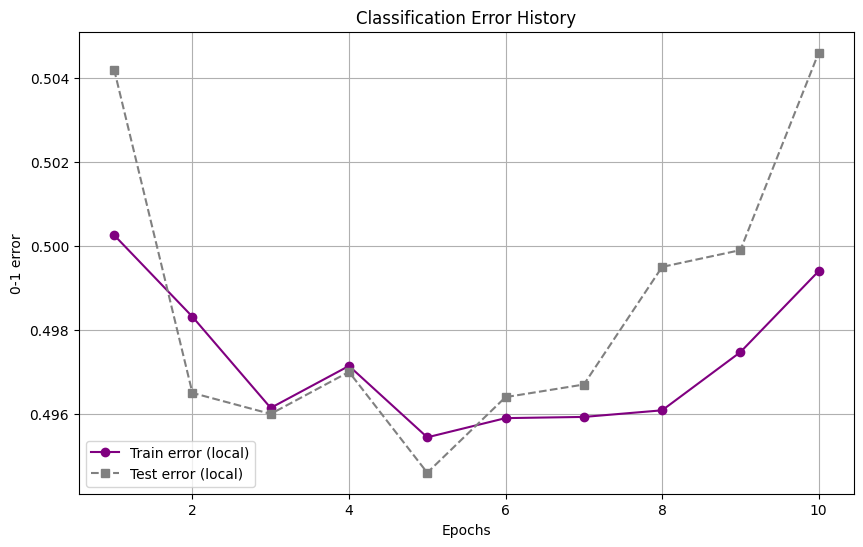

In [87]:
plot_error_history(error_train_history_random, error_test_history_random, num_epochs)

In [ ]:
model_random_sgd = FC600().to(device)
error_test_history_random_sgd = []
error_train_history_random_sgd = []

loss_fn = nn.BCELoss()

optimizer = torch.optim.SGD(
    model_random_sgd.parameters(),
    lr=0.1,
    momentum=0.9
)

num_epochs = 10
print(f"Training on {device}...")
for epoch in range(num_epochs):

    model_random_sgd.train()
    
    for inputs, targets in train_loader_random:

        x = inputs.to(device)
        target = targets.float().unsqueeze(1).to(device)

        probs = model_random_sgd(x)
        loss = loss_fn(probs, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model_random_sgd.eval()
    correct = 0
    total = 0
    with torch.no_grad():

        for inputs, targets in test_loader_random:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_random_sgd(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_test_random_sgd = (1 - correct / total)*100

        error_test_history_random_sgd.append(error_test_random_sgd/100)

        for inputs, targets in train_loader_random:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_random_sgd(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_train_random_sgd = (1 - correct / total)*100

        error_train_history_random_sgd.append(error_train_random_sgd/100)
    

    print(f"Epoch {epoch+1}/{num_epochs} completed | Train Error: {error_train_random_sgd:.2f}% | Test Error: {error_test_random_sgd:.2f}% ")

Training on cuda...
Epoch 1/10 completed | Train Error: 49.17% | Test Error: 49.02% 
Epoch 2/10 completed | Train Error: 48.70% | Test Error: 49.21% 
Epoch 3/10 completed | Train Error: 48.20% | Test Error: 49.01% 
Epoch 4/10 completed | Train Error: 46.13% | Test Error: 49.38% 
Epoch 5/10 completed | Train Error: 46.49% | Test Error: 49.32% 
Epoch 6/10 completed | Train Error: 47.83% | Test Error: 50.79% 
Epoch 7/10 completed | Train Error: 44.55% | Test Error: 49.51% 
Epoch 8/10 completed | Train Error: 43.87% | Test Error: 49.58% 
Epoch 9/10 completed | Train Error: 44.27% | Test Error: 50.62% 
Epoch 10/10 completed | Train Error: 42.13% | Test Error: 50.10% 


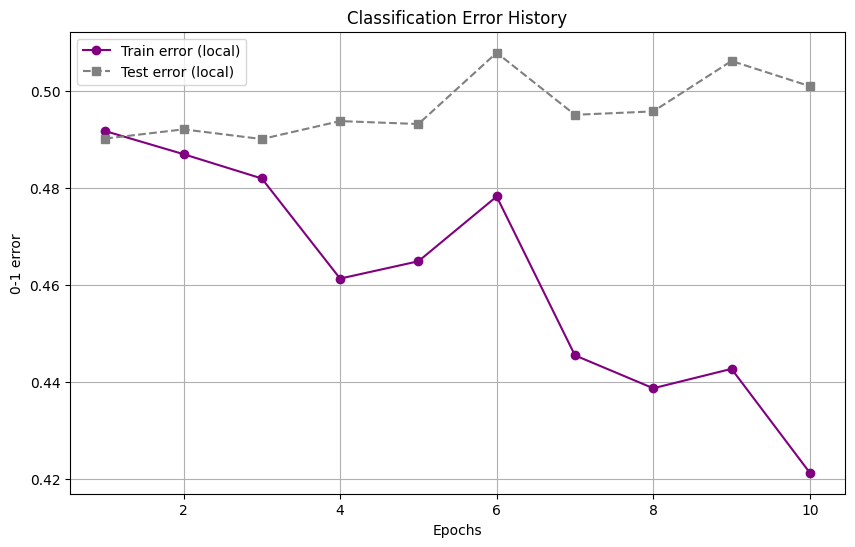

In [114]:
plot_error_history(error_train_history_random_sgd, error_test_history_random_sgd, num_epochs)

We see that there is overfitting using SGD compared to entropy-SGLD

---

### Test with a FashionMNIST (still Binary class)

In [ ]:
transform = transforms.ToTensor()

# On charge FashionMNIST au lieu de MNIST
train_dataset_bis = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_bis = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Binarisation : Les vêtements de 0 à 4 deviennent "1", de 5 à 9 deviennent "0"
train_dataset_bis.targets = (train_dataset_bis.targets < 5).long()
test_dataset_bis.targets = (test_dataset_bis.targets < 5).long()



train_loader_fashion = DataLoader(train_dataset_bis, batch_size=K, shuffle=True)
test_loader_fashion = DataLoader(test_dataset_bis, batch_size=K, shuffle=False)

Hyperparametres

In [120]:
m = len(train_dataset_bis) 
L = 20
gamma = 1.0
tau = math.sqrt(m)
beta = 100.0 
alpha = 0.75
eta_prime_base = 1 


num_epochs = 30
global_t_outer = 1
steps_per_epoch = len(train_loader_fashion) // L 

In [122]:
print(f"Training on {device}...")


model_fashion = FC600().to(device)

error_test_history_fashion = []
error_train_history_fashion = []

for epoch in range(1, num_epochs + 1):
    # Training
    model_fashion.train()
    
    data_iter = iter(train_loader_fashion)
    
    for step in range(steps_per_epoch):
        batches_list = []
        for _ in range(L):
            batches_list.append(next(data_iter))
            
        # entropy_sgld_step
        entropy_sgld_step(model_fashion, batches_list, global_t_outer, m=m, L=L, gamma=gamma, tau=tau, beta=beta, alpha=alpha, eta_prime_base=eta_prime_base)
        global_t_outer += 1
        
    # Evaluation
    model_fashion.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in test_loader_fashion:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_fashion(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_test = (1 - correct / total)*100

        error_test_history_fashion.append(error_test/100)

        for inputs, targets in train_loader_fashion:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_fashion(inputs).squeeze()
            predicted = (probs >= 0.5).long()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        error_train = (1 - correct / total)*100

        error_train_history_fashion.append(error_train/100)

    print(f"Epoch {epoch}/{num_epochs} completed | Train Error: {error_train:.2f}% | Test Error: {error_test:.2f}% ")

Training on cuda...
Epoch 1/30 completed | Train Error: 41.75% | Test Error: 41.31% 
Epoch 2/30 completed | Train Error: 17.82% | Test Error: 17.68% 
Epoch 3/30 completed | Train Error: 12.52% | Test Error: 12.47% 
Epoch 4/30 completed | Train Error: 11.84% | Test Error: 11.73% 
Epoch 5/30 completed | Train Error: 11.49% | Test Error: 11.54% 
Epoch 6/30 completed | Train Error: 11.40% | Test Error: 11.45% 
Epoch 7/30 completed | Train Error: 11.41% | Test Error: 11.51% 
Epoch 8/30 completed | Train Error: 11.31% | Test Error: 11.33% 
Epoch 9/30 completed | Train Error: 11.32% | Test Error: 11.38% 
Epoch 10/30 completed | Train Error: 11.25% | Test Error: 11.21% 
Epoch 11/30 completed | Train Error: 11.09% | Test Error: 11.09% 
Epoch 12/30 completed | Train Error: 11.14% | Test Error: 11.10% 
Epoch 13/30 completed | Train Error: 11.08% | Test Error: 11.02% 
Epoch 14/30 completed | Train Error: 11.05% | Test Error: 11.01% 
Epoch 15/30 completed | Train Error: 11.01% | Test Error: 11.03% 

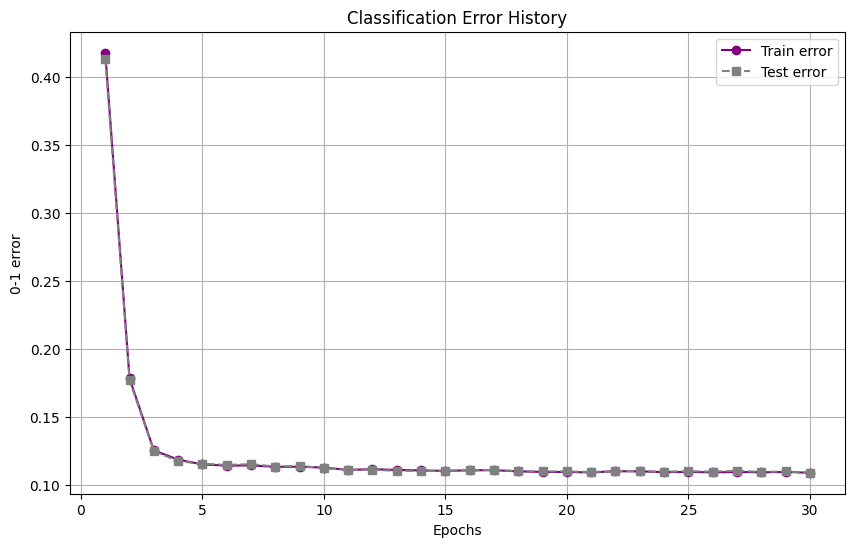

In [126]:
plot_error_history(error_train_history_fashion, error_test_history_fashion, num_epochs)

There is a huge decrease at the beginning and it keeps decreasing after, maybe with more epochs and higher noise we could obtain better errors but it is still satisfying.

---

We tried to implement the computation of the PAC Bound using the information in the annex. Following the step with obtain the code below.

Sadly after different try, our kl was not accurate and was even negative some times. After a lot of trying we decided to give up this trying to concentrate on the main algorithm and it tests.

In [127]:
def compute_empirical_risk(model_eval, dataloader, device):
    #Calculates the mean empirical risk (loss) over the entire dataset


    model_eval.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            probs = model_eval(inputs)
            loss = bounded_binary_cross_entropy_loss(probs, targets)
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)
    return total_loss / total_samples

def estimate_kl_divergence(model_mean, train_loader, tau, gamma, device, k_samples=20):
    #Estimates KL divergence using Monte Carlo (Appendix C.3.2).


    prior_variance = 1.0 / (tau * gamma)
    w_mean = [p.clone().detach() for p in model_mean.parameters()]

    # First term: E_{w ~ P_{exp(-l)}}[-l(w)] (SGLD Samples)
    term1_vals = []
    sgld_model = copy.deepcopy(model_mean)
    sgld_model.train()

    # Specific SGLD parameters for KL estimation
    alpha_kl = 0.005
    eta_inner_rescaled = 0.1 

    data_iter = iter(train_loader)

    for k in range(k_samples):
        try:
            inputs, targets = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            inputs, targets = next(data_iter)

        inputs, targets = inputs.to(device), targets.to(device)

        # A simplified SGLD step to sample w'
        probs = sgld_model(inputs)
        loss = bounded_binary_cross_entropy_loss(probs, targets)
        sgld_model.zero_grad()
        loss.backward()

        with torch.no_grad():
            for p_sgld, p_mean in zip(sgld_model.parameters(), w_mean):
                # dw = -grad - gamma * (w' - w_mean)
                dw = -p_sgld.grad - gamma * (p_sgld.data - p_mean.data)
                noise = torch.randn_like(p_sgld) * math.sqrt(eta_inner_rescaled * 2.0 / tau)
                # Update
                p_sgld.add_(eta_inner_rescaled * dw + noise)

        # Evaluate empirical risk on the entire dataset with this w'
        r_s = compute_empirical_risk(sgld_model, train_loader, device)
        l_w = tau * r_s
        term1_vals.append(-l_w)

    term1 = sum(term1_vals) / len(term1_vals)

    # Second term: - log P[exp(-l)] (Gaussian Samples)
    term2_l_vals = []
    h_model = copy.deepcopy(model_mean)

    for k in range(k_samples):
        with torch.no_grad():
            # h_i are drawn i.i.d from the prior distribution P
            for p, p_mean in zip(h_model.parameters(), w_mean):
                noise = torch.randn_like(p_mean) * math.sqrt(prior_variance)
                p.copy_(p_mean + noise)

        r_s = compute_empirical_risk(h_model, train_loader, device)
        l_h = tau * r_s
        term2_l_vals.append(-l_h)

    # LogSumExp 
    term2_tensor = torch.tensor(term2_l_vals)
    log_sum_exp = torch.logsumexp(term2_tensor, dim=0).item()
    term2 = log_sum_exp - math.log(k_samples)

    kl_estimate = term1 - term2
    return kl_estimate

In [128]:
def binary_kl(q, p):
    #Computes the KL divergence between two Bernoulli distributions (q and p)
    if q == 0.0:
        return -math.log(1.0 - p) if p < 1.0 else float('inf')
    if q == 1.0:
        return -math.log(p) if p > 0.0 else float('inf')
    if p == 0.0 or p == 1.0:
        return float('inf')

    return q * math.log(q / p) + (1.0 - q) * math.log((1.0 - q) / (1.0 - p))

def compute_pac_bayes_bound(kl_divergence, train_error_01, m, tau, beta=1.0, L_max=4.0, delta=0.05):
    # Calculates the  PAC-Bayes bound of Theorem 4.5

    # Calculate the differential privacy penalty (epsilon)
    epsilon = (2.0 * beta * L_max * tau) / m

    # Calculate the right-hand side term (c) 
    term1 = kl_divergence
    term2 = math.log(2.0 * math.sqrt(m) / delta)
    term3 = 2.0 * max(math.log(3.0 / delta), m * (epsilon ** 2))

    c = (term1 + term2 + term3) / m

    # Invert the binary KL to find the test error (p)
    q = train_error_01

    def objective_func(p):
        return binary_kl(q, p) - c

    # Find the root using Brent's method 
    try:
        p_bound = opt.brentq(objective_func, q + 1e-9, 0.9999)
    except ValueError:
        # If no solution is found, the bound is likely >= 1
        p_bound = 1.0

    return p_bound